## Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import sawtooth
import scipy
from astropy.table import Table
from scipy.stats import chi2

In [2]:
import iminuit

from iminuit import minimize  # has same interface as scipy.optimize.minimize
from iminuit import Minuit, describe

# we also need a cost function to fit and import the LeastSquares function
from iminuit.cost import LeastSquares
from iminuit.cost import UnbinnedNLL

# Annotated and Gt are imported from iminuit.typing here for universal compatibility,
# but users should in general import them from external packages `typing-extensions` and
# `annotated-types` to decouple models from the `iminuit` package
from iminuit.typing import Annotated, Gt

%config InlineBackend.figure_formats = ['svg']

from iminuit import Minuit

print("iminuit version:", iminuit.__version__)

iminuit version: 2.30.0


## Functions

In [3]:
def read(filename):
    data = pd.read_csv(filename, sep="\\s+", header=None, skiprows=2)
    data.columns = ['time','flux','flux_err']
    return data

In [4]:
def sin(x, A, omega, phi0):
    y = A*np.sin(omega*x + phi0)
    return y

def saw(x, A, omega, phi0):
    y = A*sawtooth(omega*x + phi0, 0)
    return y

In [5]:
def fit(filename, initial_guess, function, n):
    data=read(filename)
    A, omega, phi0 = initial_guess
    
    least_squares = LeastSquares(data['time'],data['flux'],data['flux_err'], function)
    m = Minuit(least_squares, A=A, omega=omega, phi0=phi0)  

    time=data['time']
    distance=np.zeros(len(time)-1)
    for i in range(len(time)-1):
        distance[i]=np.abs(time[i]-time[i+1])
    
    omega_max=2*np.pi/np.min(distance)

    m.limits['A'] = (min(abs(data['flux'])),2*(max(data['flux'])-min(data['flux'])))
    m.limits['omega'] = (2*np.pi/(max(data['time'])-min(data['time'])), omega_max) #nel caso si può omettere il due e tornare ad mezzo periodo
    m.limits['phi0'] = (0,2*np.pi)
    
    m.migrad()
    chi2=m.fval/(len(data['time'])-n)

    return m, chi2

In [43]:
def name(num):
    if num<1000:
        file='../lc_0'+str(num)+'.txt'
    if num<100:
        file='../lc_00'+str(num)+'.txt'
    if num<10:
        file='../lc_000'+str(num)+'.txt'
    return file

# Fitting Models and Saving Parameters

In [7]:
n_param=3

In [8]:
initial_guess=[1,0,0] #io metterei 1 di initial guess per A

In [9]:
m_vector_sin=np.array([])
m_vector_saw=np.array([])
chi2_vector_sin=np.array([])
chi2_vector_saw=np.array([])

In [12]:
with open("sin.txt", "w") as f:
    f.write("chi2 ")
    f.write("A ")
    f.write("omega ")
    f.write("phi0 \n")

for i in range(1000):
    
    if i<1000:
        file='../lc_0'+str(i)+'.txt'
    if i<100:
        file='../lc_00'+str(i)+'.txt'
    if i<10:
        file='../lc_000'+str(i)+'.txt'

    data=read(file)
    omega_min=np.pi/(max(data['time'])-min(data['time']))

    #time=data['time']
    #distance=np.zeros(len(time)-1)
    #for i in range(len(time)-1):
    #    distance[i]=np.abs(time[i]-time[i+1])
    
    #omega_max=2*np.pi/np.min(distance)
    omega_max=0.1
    omega_vector=np.arange(omega_min,omega_max,0.001)
    print(len(omega_vector))


    chi2_vector_sin_omega=np.array([])
    m_vector_sin_omega=np.array([])
    
    for omega in omega_vector:
        initial_guess[1]=omega
    
        m_sin, chi2_sin=fit(file,initial_guess, sin, n_param)
        m_vector_sin_omega=np.append(m_vector_sin_omega,m_sin)
        chi2_vector_sin_omega=np.append(chi2_vector_sin_omega,chi2_sin)

    chi2_sin=np.min(chi2_vector_sin_omega)
    argmin_sin=np.argmin(chi2_vector_sin_omega)
    m_sin=m_vector_sin_omega[argmin_sin]
    
    params_sin=iminuit.util.ValueView(m_sin)

    with open("sin.txt", "a") as f:
        f.write(str(chi2_sin)+ " ")
        f.write(str(params_sin[0])+ " ")
        f.write(str(params_sin[1])+ " ")
        f.write(str(params_sin[2])+ "\n")
    
    m_vector_sin=np.append(m_vector_sin,m_sin)
    chi2_vector_sin=np.append(chi2_vector_sin,chi2_sin)
    
    print(file, "sin done")

98
../lc_0000.txt sin done
99
../lc_0001.txt sin done
99
../lc_0002.txt sin done
99
../lc_0003.txt sin done
99
../lc_0004.txt sin done
99
../lc_0005.txt sin done
99
../lc_0006.txt sin done
99
../lc_0007.txt sin done
99
../lc_0008.txt sin done
99
../lc_0009.txt sin done
99
../lc_0010.txt sin done
99
../lc_0011.txt sin done
99
../lc_0012.txt sin done
99
../lc_0013.txt sin done
98
../lc_0014.txt sin done
99
../lc_0015.txt sin done
99
../lc_0016.txt sin done
98
../lc_0017.txt sin done
99
../lc_0018.txt sin done
98
../lc_0019.txt sin done
99
../lc_0020.txt sin done
98
../lc_0021.txt sin done
99
../lc_0022.txt sin done
99
../lc_0023.txt sin done
99
../lc_0024.txt sin done
99
../lc_0025.txt sin done
99
../lc_0026.txt sin done
99
../lc_0027.txt sin done
98
../lc_0028.txt sin done
99
../lc_0029.txt sin done
100
../lc_0030.txt sin done
100
../lc_0031.txt sin done
99
../lc_0032.txt sin done
99
../lc_0033.txt sin done
99
../lc_0034.txt sin done
98
../lc_0035.txt sin done
99
../lc_0036.txt sin done

In [21]:
with open("saw.txt", "w") as f:
    f.write("chi2 ")
    f.write("A ")
    f.write("omega ")
    f.write("phi0 \n")

for i in range(1000):
    
    if i<1000:
        file='../lc_0'+str(i)+'.txt'
    if i<100:
        file='../lc_00'+str(i)+'.txt'
    if i<10:
        file='../lc_000'+str(i)+'.txt'

    data=read(file)
    omega_min=np.pi/(max(data['time'])-min(data['time']))

    #time=data['time']
    #distance=np.zeros(len(time)-1)
    #for j in range(len(time)-1):
    #distance[j]=np.abs(time[j]-time[j+1])
    
    #omega_max=2*np.pi/np.min(distance)
    omega_max=0.1
    omega_vector=np.arange(omega_min,omega_max,0.001)
    print(len(omega_vector))

    chi2_vector_saw_omega=np.array([])
    m_vector_saw_omega=np.array([])

    for omega in omega_vector:
        initial_guess[1]=omega
        
        m_saw, chi2_saw=fit(file,initial_guess, saw, n_param)
        m_vector_saw_omega=np.append(m_vector_saw_omega,m_saw)
        chi2_vector_saw_omega=np.append(chi2_vector_saw_omega,chi2_saw)

    chi2_saw=np.min(chi2_vector_saw_omega)
    argmin_saw=np.argmin(chi2_vector_saw_omega)
    m_saw=m_vector_saw_omega[argmin_saw]

    params_saw=iminuit.util.ValueView(m_saw)

    with open("saw.txt", "a") as f:
        f.write(str(chi2_saw)+ " ")
        f.write(str(params_saw[0])+ " ")
        f.write(str(params_saw[1])+ " ")
        f.write(str(params_saw[2])+ "\n")
    
    m_vector_saw=np.append(m_vector_saw,m_saw)
    chi2_vector_saw=np.append(chi2_vector_saw,chi2_saw)

    print(file, "saw done")

99
../lc_0500.txt saw done
99
../lc_0501.txt saw done
99
../lc_0502.txt saw done
99
../lc_0503.txt saw done
99
../lc_0504.txt saw done
99
../lc_0505.txt saw done
100
../lc_0506.txt saw done
98
../lc_0507.txt saw done
99
../lc_0508.txt saw done
99
../lc_0509.txt saw done
99
../lc_0510.txt saw done
100
../lc_0511.txt saw done
99
../lc_0512.txt saw done
99
../lc_0513.txt saw done
99
../lc_0514.txt saw done
98
../lc_0515.txt saw done
99
../lc_0516.txt saw done
99
../lc_0517.txt saw done
99
../lc_0518.txt saw done
99
../lc_0519.txt saw done
99
../lc_0520.txt saw done
99
../lc_0521.txt saw done
98
../lc_0522.txt saw done
99
../lc_0523.txt saw done
99
../lc_0524.txt saw done
99
../lc_0525.txt saw done
98
../lc_0526.txt saw done
99
../lc_0527.txt saw done
99
../lc_0528.txt saw done
99
../lc_0529.txt saw done
99
../lc_0530.txt saw done
99
../lc_0531.txt saw done
98
../lc_0532.txt saw done
98
../lc_0533.txt saw done
100
../lc_0534.txt saw done
99
../lc_0535.txt saw done
99
../lc_0536.txt saw don

# Reading Parameters

In [32]:
chi2_vector_sin=np.array([])
chi2_vector_saw=np.array([])

A_sin=np.array([])
omega_sin=np.array([])
phi_sin=np.array([])

A_saw=np.array([])
omega_saw=np.array([])
phi_saw=np.array([])

with open("sin.txt", "r") as f:
    for line in f:
        columns = line.split()
        if columns[0]=='chi2': continue
        chi2_vector_sin=np.append(chi2_vector_sin,float(columns[0]))
        A_sin=np.append(A_sin,float(columns[1]))
        omega_sin=np.append(omega_sin,float(columns[2]))
        phi_sin=np.append(phi_sin,float(columns[3]))

with open("saw.txt", "r") as f:
    for line in f:
        columns = line.split()
        if columns[0]=='chi2': continue
        chi2_vector_saw=np.append(chi2_vector_saw,float(columns[0]))
        A_saw=np.append(A_saw,float(columns[1]))
        omega_saw=np.append(omega_saw,float(columns[2]))
        phi_saw=np.append(phi_saw,float(columns[3]))

In [33]:
length=np.zeros(1000)

Table_sin = Table([length,length,length,length],names=('chi2', 'A', 'omega', 'phi'), dtype=('f4', 'f8', 'f8', 'f8'))
Table_saw = Table([length,length,length,length],names=('chi2', 'A', 'omega', 'phi'), dtype=('f4', 'f8', 'f8', 'f8'))

In [34]:
Table_sin['chi2'] = chi2_vector_sin
Table_sin['A'] = A_sin
Table_sin['omega'] = omega_sin
Table_sin['phi'] = phi_sin

Table_saw['chi2'] = chi2_vector_saw
Table_saw['A'] = A_saw
Table_saw['omega'] = omega_saw
Table_saw['phi'] = phi_saw

In [35]:
#Table_sin, Table_saw

Big problems, I need to mask, let's do it

# Statistical Analysis

## Chi squared

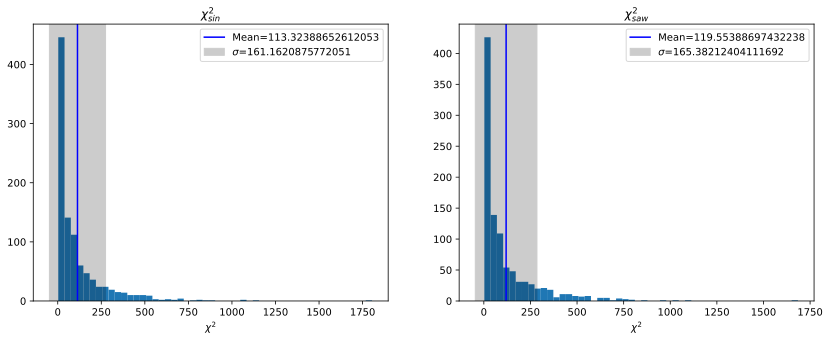

In [36]:
fig=plt.figure(figsize=(14,5))
ax0=fig.add_subplot(121)
ax1=fig.add_subplot(122)

ax0.hist(chi2_vector_sin, bins=50)
ax1.hist(chi2_vector_saw, bins=50)

ax0.set_xlabel(r'$\chi^2$')
ax0.set_title(r'$\chi^2_{sin}$')

ax1.set_xlabel(r'$\chi^2$')
ax1.set_title(r'$\chi^2_{saw}$')

mean_chi2_sin=np.mean(chi2_vector_sin)
mean_chi2_saw=np.mean(chi2_vector_saw)

ax0.axvline(mean_chi2_sin,c='b', label='Mean='+str(mean_chi2_sin))
ax1.axvline(mean_chi2_saw,c='b', label='Mean='+str(mean_chi2_saw))

std_chi2_sin=np.std(chi2_vector_sin)
std_chi2_saw=np.std(chi2_vector_saw)

ax0.axvspan(mean_chi2_sin-std_chi2_sin,mean_chi2_sin+std_chi2_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_chi2_sin))
ax1.axvspan(mean_chi2_saw-std_chi2_saw,mean_chi2_saw+std_chi2_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_chi2_saw))

ax0.legend(loc='upper right')
ax1.legend(loc='upper right');

Mean: -6.230000448201823
Standard Deviation: 36.301139043103944
Skewness: -4.1426013187360615
Kurtosis: 36.96494030113357

The number of samples in which the sawtooth model works better than the sinusoid is 371
The number of samples in which the sinusoid model works better than the sawtooth is 629
The number of samples in which the sawtooth model works as effectively as the sinusoid is 0



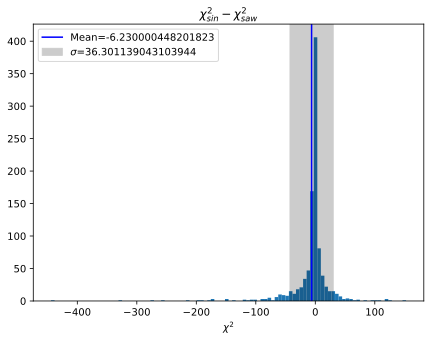

In [37]:
fig=plt.figure(figsize=(7,5))

delta_chi=chi2_vector_sin-chi2_vector_saw
plt.hist(delta_chi, bins=100);
plt.xlabel(r'$\chi^2$')
plt.title(r'$\chi^2_{sin}-\chi^2_{saw}$')

chi_distribution=delta_chi
chi_mean=np.mean(chi_distribution)
chi_std=np.std(chi_distribution)
chi_skew=scipy.stats.skew(chi_distribution)
chi_kurt=scipy.stats.kurtosis(chi_distribution)

plt.axvline(chi_mean,c='b', label='Mean='+str(chi_mean))
plt.axvspan(chi_mean-chi_std,chi_mean+chi_std,0,500, alpha=0.2, color='k', label=r'$\sigma$='+str(chi_std))

plt.legend(loc='upper left')

print("Mean:", chi_mean)
print("Standard Deviation:",chi_std)
print("Skewness:",chi_skew)
print("Kurtosis:",chi_kurt)

print()

print("The number of samples in which the sawtooth model works better than the sinusoid is", len(delta_chi[delta_chi>0]))
print("The number of samples in which the sinusoid model works better than the sawtooth is", len(delta_chi[delta_chi<0]))
print("The number of samples in which the sawtooth model works as effectively as the sinusoid is", len(delta_chi[delta_chi==0]))

print()

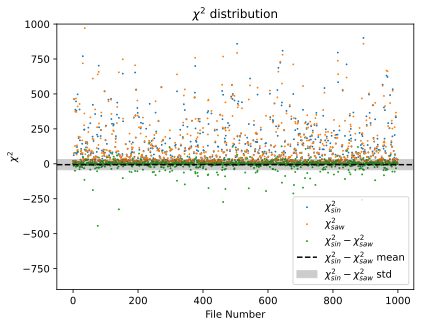

In [38]:
Nfile=np.linspace(0,999,1000)
plt.scatter(Nfile,chi2_vector_sin, s=0.8, label=r'$\chi^2_{sin}$')
plt.scatter(Nfile,chi2_vector_saw, s=0.8, label=r'$\chi^2_{saw}$')
plt.scatter(Nfile,delta_chi, s=1, label=r'$\chi^2_{sin}-\chi^2_{saw}$')
plt.axhline(chi_mean, c='k',ls='--' ,label=r'$\chi^2_{sin}-\chi^2_{saw}$ mean')
plt.axhspan(chi_mean-chi_std,chi_mean+chi_std,0,500, alpha=0.2, color='k', label=r'$\chi^2_{sin}-\chi^2_{saw}$ std')

plt.ylim(-900,1000)
plt.ylabel(r'$\chi^2$')
plt.xlabel("File Number")
plt.title(r'$\chi^2$ distribution')
plt.legend(loc='best');

## Fit Parameters

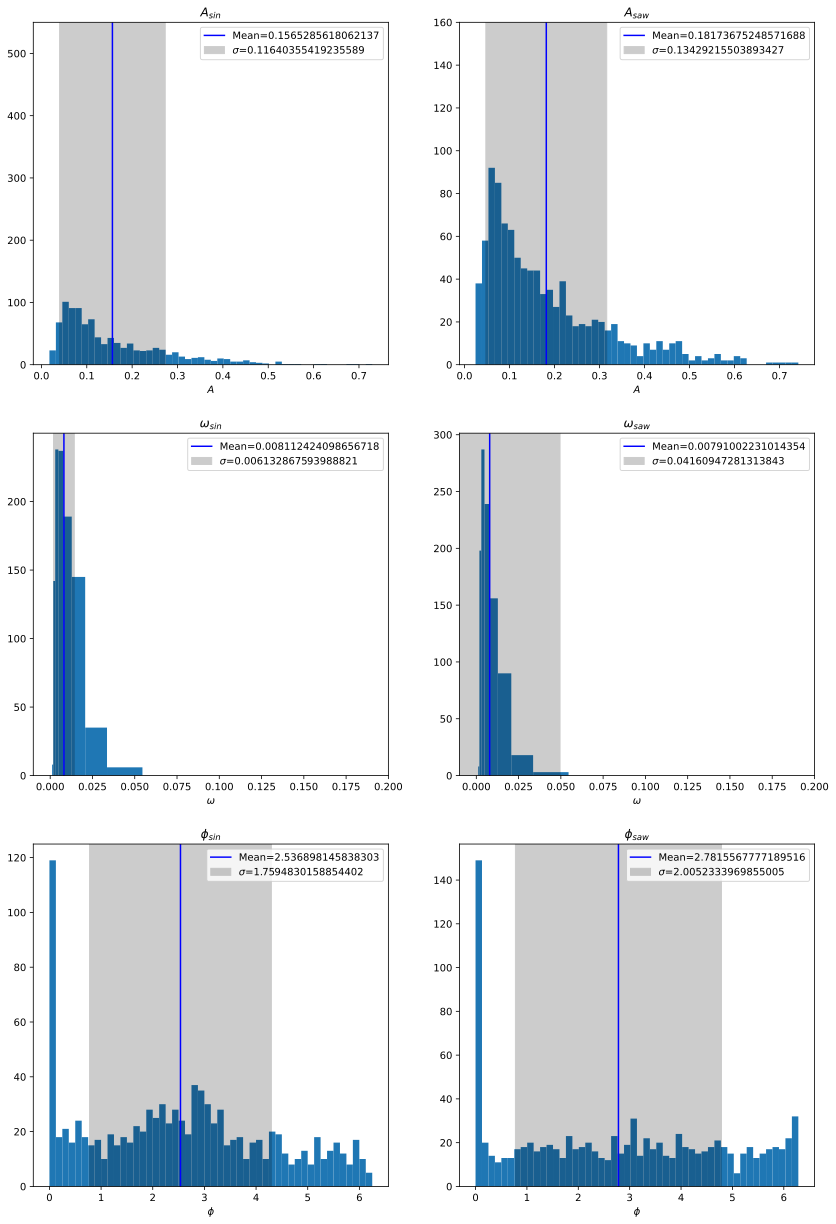

In [39]:
fig=plt.figure(figsize=(14,21))
ax0=fig.add_subplot(321)
ax1=fig.add_subplot(322)

ax0.hist(A_sin, bins=50)
ax1.hist(A_saw, bins=50)

ax0.set_xlabel(r'$A$')
ax0.set_title(r'$A_{sin}$')

ax1.set_xlabel(r'$A$')
ax1.set_title(r'$A_{saw}$')

mean_A_sin=np.mean(A_sin)
mean_A_saw=np.mean(A_saw)

ax0.axvline(mean_A_sin,c='b', label='Mean='+str(mean_A_sin))
ax1.axvline(mean_A_saw,c='b', label='Mean='+str(mean_A_saw))

std_A_sin=np.std(A_sin)
std_A_saw=np.std(A_saw)

ax0.axvspan(mean_A_sin-std_A_sin,mean_A_sin+std_A_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_A_sin))
ax1.axvspan(mean_A_saw-std_A_saw,mean_A_saw+std_A_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_A_saw))

ax0.set_ylim(0,550)
ax1.set_ylim(0,160)


ax0.legend(loc='best')
ax1.legend(loc='best');


ax0=fig.add_subplot(323)
ax1=fig.add_subplot(324)

bins = np.logspace(-4,0,20)

ax0.hist(omega_sin, bins=bins)
ax1.hist(omega_saw, bins=bins)

ax0.set_xlim(-0.01,0.2)
ax1.set_xlim(-0.01,0.2)


ax0.set_xlabel(r'$\omega$')
ax0.set_title(r'$\omega_{sin}$')

ax1.set_xlabel(r'$\omega$')
ax1.set_title(r'$\omega_{saw}$')

mean_omega_sin=np.mean(omega_sin)
mean_omega_saw=np.mean(omega_saw)

ax0.axvline(mean_omega_sin,c='b', label='Mean='+str(mean_omega_sin))
ax1.axvline(mean_omega_saw,c='b', label='Mean='+str(mean_omega_saw))

std_omega_sin=np.std(omega_sin)
std_omega_saw=np.std(omega_saw)

ax0.axvspan(mean_omega_sin-std_omega_sin,mean_omega_sin+std_omega_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_omega_sin))
ax1.axvspan(mean_omega_saw-std_omega_saw,mean_omega_saw+std_omega_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_omega_saw))

ax0.legend(loc='best')
ax1.legend(loc='best');


ax0=fig.add_subplot(325)
ax1=fig.add_subplot(326)

ax0.hist(phi_sin, bins=50)
ax1.hist(phi_saw, bins=50)

ax0.set_xlabel(r'$\phi$')
ax0.set_title(r'$\phi_{sin}$')

ax1.set_xlabel(r'$\phi$')
ax1.set_title(r'$\phi_{saw}$')

mean_phi_sin=np.mean(phi_sin)
mean_phi_saw=np.mean(phi_saw)

ax0.axvline(mean_phi_sin,c='b', label='Mean='+str(mean_phi_sin))
ax1.axvline(mean_phi_saw,c='b', label='Mean='+str(mean_phi_saw))

std_phi_sin=np.std(phi_sin)
std_phi_saw=np.std(phi_saw)

ax0.axvspan(mean_phi_sin-std_phi_sin,mean_phi_sin+std_phi_sin,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_phi_sin))
ax1.axvspan(mean_phi_saw-std_phi_saw,mean_phi_saw+std_phi_saw,0,300, alpha=0.2, color='k', label=r'$\sigma$='+str(std_phi_saw))

ax0.legend(loc='best')
ax1.legend(loc='best');

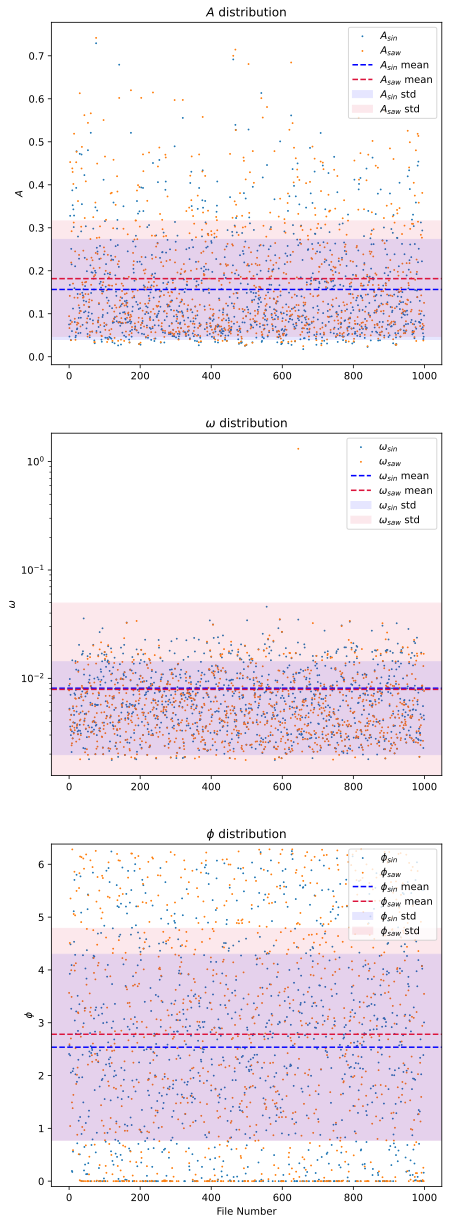

In [40]:
Nfile=np.linspace(0,999,1000)

fig=plt.figure(figsize=(7,21))
ax0=fig.add_subplot(311)
ax1=fig.add_subplot(312)
ax2=fig.add_subplot(313)

ax0.scatter(Nfile,A_sin, s=0.8, label=r'$A_{sin}$')
ax0.scatter(Nfile,A_saw, s=0.8, label=r'$A_{saw}$')

ax0.axhline(mean_A_sin, c='b',ls='--', label=r'$A_{sin}$ mean')
ax0.axhline(mean_A_saw, c='crimson',ls='--', label=r'$A_{saw}$ mean')
ax0.axhspan(mean_A_sin-std_A_sin,mean_A_sin+std_A_sin,0,500, alpha=0.1, color='b', label=r'$A_{sin}$ std')
ax0.axhspan(mean_A_saw-std_A_saw,mean_A_saw+std_A_saw,0,500, alpha=0.1, color='crimson', label=r'$A_{saw}$ std')

ax0.set_ylabel(r'$A$')
ax0.set_title(r'$A$ distribution')
ax0.legend(loc='best')

ax1.scatter(Nfile,omega_sin, s=0.8, label=r'$\omega_{sin}$')
ax1.scatter(Nfile,omega_saw, s=0.8, label=r'$\omega_{saw}$')

ax1.axhline(mean_omega_sin, c='b',ls='--', label=r'$\omega_{sin}$ mean')
ax1.axhline(mean_omega_saw, c='crimson',ls='--', label=r'$\omega_{saw}$ mean')
ax1.axhspan(mean_omega_sin-std_omega_sin,mean_omega_sin+std_omega_sin,0,500, alpha=0.1, color='b', label=r'$\omega_{sin}$ std')
ax1.axhspan(mean_omega_saw-std_omega_saw,mean_omega_saw+std_omega_saw,0,500, alpha=0.1, color='crimson', label=r'$\omega_{saw}$ std')

#ax1.set_ylim(-0.01,0.2)
ax1.set_yscale('log')
ax1.set_ylabel(r'$\omega$')
ax1.set_title(r'$\omega$ distribution')
ax1.legend(loc='best');

ax2.scatter(Nfile,phi_sin, s=0.8, label=r'$\phi_{sin}$')
ax2.scatter(Nfile,phi_saw, s=0.8, label=r'$\phi_{saw}$')

ax2.axhline(mean_phi_sin, c='b',ls='--', label=r'$\phi_{sin}$ mean')
ax2.axhline(mean_phi_saw, c='crimson',ls='--', label=r'$\phi_{saw}$ mean')
ax2.axhspan(mean_phi_sin-std_phi_sin,mean_phi_sin+std_phi_sin,0,500, alpha=0.1, color='b', label=r'$\phi_{sin}$ std')
ax2.axhspan(mean_phi_saw-std_phi_saw,mean_phi_saw+std_phi_saw,0,500, alpha=0.1, color='crimson', label=r'$\phi_{saw}$ std')

ax2.set_ylim(-0.1,2*np.pi+0.1)
ax2.set_ylabel(r'$\phi$')
ax2.set_title(r'$\phi$ distribution')
ax2.legend(loc='best');

ax2.set_xlabel("File Number");

There's clearly a big outlier in $\phi_{saw}$ that needs to be addressed

### Bestfit

In [41]:
file_min_sin=np.argmin(chi2_vector_sin)
min_sin_sin=chi2_vector_sin[file_min_sin]
min_sin_saw=chi2_vector_saw[file_min_sin]

print("The minimum value for the sin models is found in the file "+str(file_min_sin))
print("The correspondent chi squared for the sinusoidal model is",min_sin_sin,"while the correspondent chi squared for the sawtooth model is",min_sin_saw)

print()

file_min_saw=np.argmin(chi2_vector_saw)
min_saw_sin=chi2_vector_sin[file_min_saw]
min_saw_saw=chi2_vector_saw[file_min_saw]

print("The minimum value for the sin models is found in the file "+str(file_min_saw))
print("The correspondent chi squared for the sinusoidal model is",min_saw_sin,"while the correspondent chi squared for the sawtooth model is",min_saw_saw)

The minimum value for the sin models is found in the file 659
The correspondent chi squared for the sinusoidal model is 3.057995995688261 while the correspondent chi squared for the sawtooth model is 2.808554576686205

The minimum value for the sin models is found in the file 659
The correspondent chi squared for the sinusoidal model is 3.057995995688261 while the correspondent chi squared for the sawtooth model is 2.808554576686205


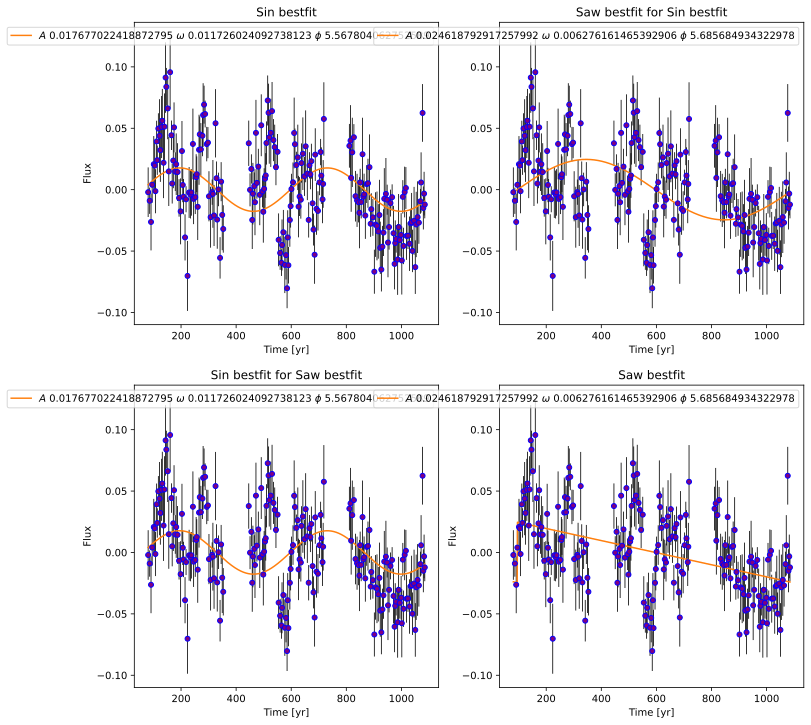

In [44]:
fig=plt.figure(figsize=(12,12))
ax0=fig.add_subplot(221)
ax1=fig.add_subplot(222)
ax2=fig.add_subplot(223)
ax3=fig.add_subplot(224)

filename_sin=name(file_min_sin)
data_sin=read(filename_sin)
ax0.errorbar(data_sin['time'],data_sin['flux'],yerr=data_sin['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_sin['time']),np.max(data_sin['time']),1000)

ax0.plot(t,sin(t,A_sin[file_min_sin],omega_sin[file_min_sin],phi_sin[file_min_sin]), label=r'$A$ '+str(A_sin[file_min_sin])+r' $\omega$ '+str(omega_sin[file_min_sin])+r' $\phi$ '+str(phi_sin[file_min_sin]))
ax0.set_xlabel('Time [yr]')
ax0.set_ylabel('Flux')
ax0.set_title('Sin bestfit')

ax0.legend(loc='best')

data_saw=read(filename_sin)
ax1.errorbar(data_saw['time'],data_saw['flux'],yerr=data_saw['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_saw['time']),np.max(data_saw['time']),1000)

ax1.plot(t,sin(t,A_saw[file_min_sin],omega_saw[file_min_sin],phi_saw[file_min_sin]), label=r'$A$ '+str(A_saw[file_min_sin])+r' $\omega$ '+str(omega_saw[file_min_sin])+r' $\phi$ '+str(phi_saw[file_min_sin]))
ax1.set_xlabel('Time [yr]')
ax1.set_title('Saw bestfit for Sin bestfit')

ax1.legend(loc='best')
         
filename_saw=name(file_min_saw)
data_sin=read(filename_saw)
ax2.errorbar(data_sin['time'],data_sin['flux'],yerr=data_sin['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_sin['time']),np.max(data_sin['time']),1000)

ax2.plot(t,sin(t,A_sin[file_min_saw],omega_sin[file_min_saw],phi_sin[file_min_saw]), label=r'$A$ '+str(A_sin[file_min_saw])+r' $\omega$ '+str(omega_sin[file_min_saw])+r' $\phi$ '+str(phi_sin[file_min_saw]))
ax2.set_xlabel('Time [yr]')
ax2.set_ylabel('Flux')
ax2.set_title('Sin bestfit for Saw bestfit')

ax2.legend(loc='best')

data_saw=read(filename_saw)
ax3.errorbar(data_saw['time'],data_saw['flux'],yerr=data_saw['flux_err'], fmt='o', ecolor='k', elinewidth=0.8, ms=5, mfc='purple',mec='b')
t=np.linspace(np.min(data_saw['time']),np.max(data_saw['time']),1000)

ax3.plot(t,saw(t,A_saw[file_min_saw],omega_saw[file_min_saw],phi_saw[file_min_saw]), label=r'$A$ '+str(A_saw[file_min_saw])+r' $\omega$ '+str(omega_saw[file_min_saw])+r' $\phi$ '+str(phi_saw[file_min_saw]))
ax3.set_xlabel('Time [yr]')
ax3.set_ylabel('Flux')
ax3.set_title('Saw bestfit')

ax3.legend(loc='best')

Fit visualization
-

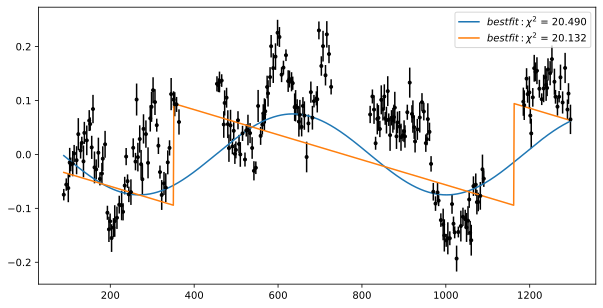

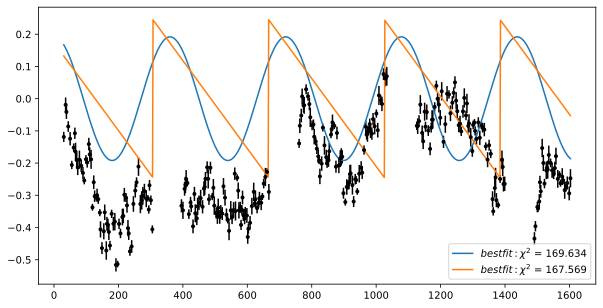

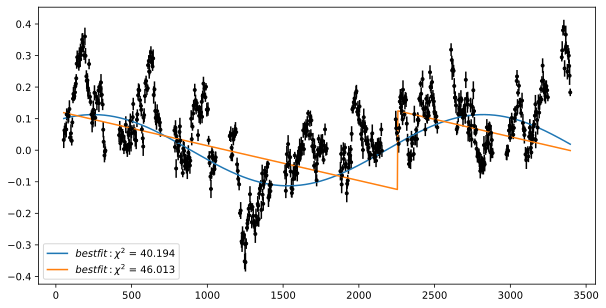

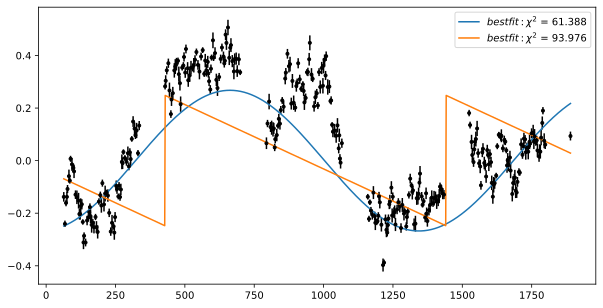

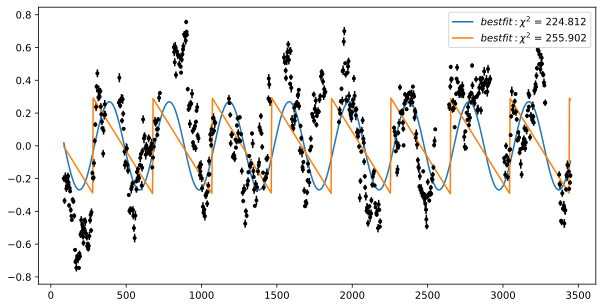

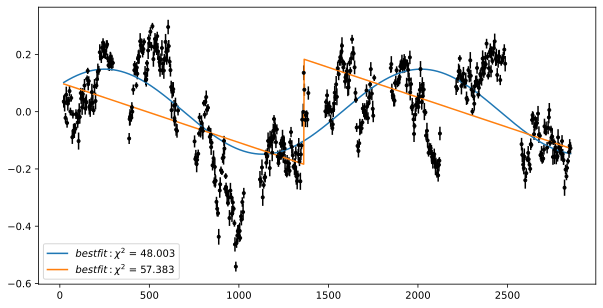

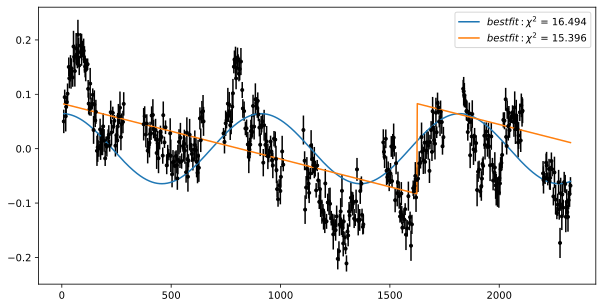

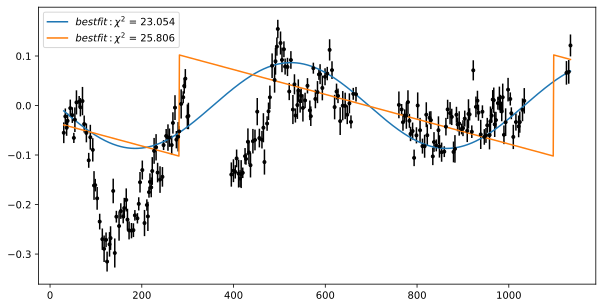

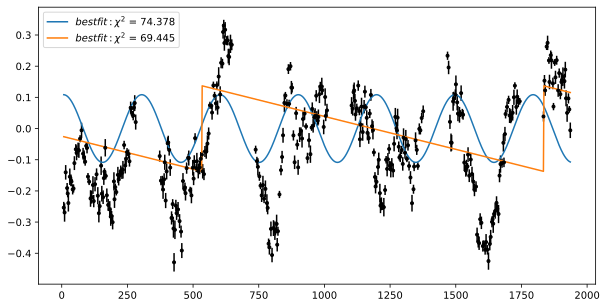

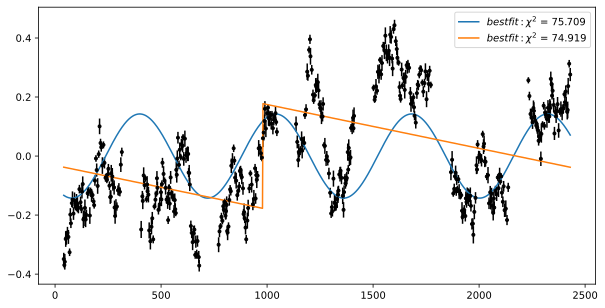

In [46]:
for imodel in range(1000)[::100]:
    fig, ax = plt.subplots(figsize=(10,5))
    file = '../lc_%04d.txt' % imodel
        
    data = pd.read_csv(file, sep="\s+", header=None, skiprows=2)
    data.columns = ['time','flux','flux_err']
    
    plt.errorbar(data['time'],data['flux'],data['flux_err'],marker='.',c='k',linestyle='')
    
    x = np.linspace(min(data['time']),max(data['time']),1000)
    
    plt.plot(x,sin(x,A_sin[imodel],omega_sin[imodel],phi_sin[imodel]),label=r'$best fit: \chi^2 $ = %.3f' % chi2_vector_sin[imodel])
    plt.plot(x,saw(x,A_saw[imodel],omega_saw[imodel],phi_saw[imodel]),label=r'$best fit: \chi^2 $ = %.3f' % chi2_vector_saw[imodel])
    plt.legend()
    plt.plot()